# IRF Tutorial

This notebook demonstrates how to compute and plot impulse response functions (IRFs) using the `irf` package.

Contents:
- Setup and data preparation
- Compute IRFs
- Plotting (single shaded, bidirectional overlay, bidirectional side-by-side, interval)



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from var_irf import compute_irf, plot_irf

np.random.seed(42)

# Generate synthetic data similar to the example
periods = 100
start_date = datetime(2023, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(periods)]

series1 = np.cumsum(np.random.normal(0, 1, periods))
x = np.linspace(0, 10, periods)
series2 = np.sin(x) + np.random.normal(0, 0.3, periods)

df = pd.DataFrame({"Series1": series1, "Series2": series2}, index=dates)
df.index.name = "Date"

df.head()


,Series1,Series2
Date,,
2023-01-01,0.496714,-0.424611
2023-01-02,0.358450,-0.025355
2023-01-03,1.006138,0.097835
2023-01-04,2.529168,0.057731
2023-01-05,2.295015,0.344751


In [3]:
# Compute IRFs
result = compute_irf(df, lags=2, horizon=7, stderr_type="asym", orth=False)
result.keys()


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


dict_keys(['values', 'stderr', 'names', 'model'])

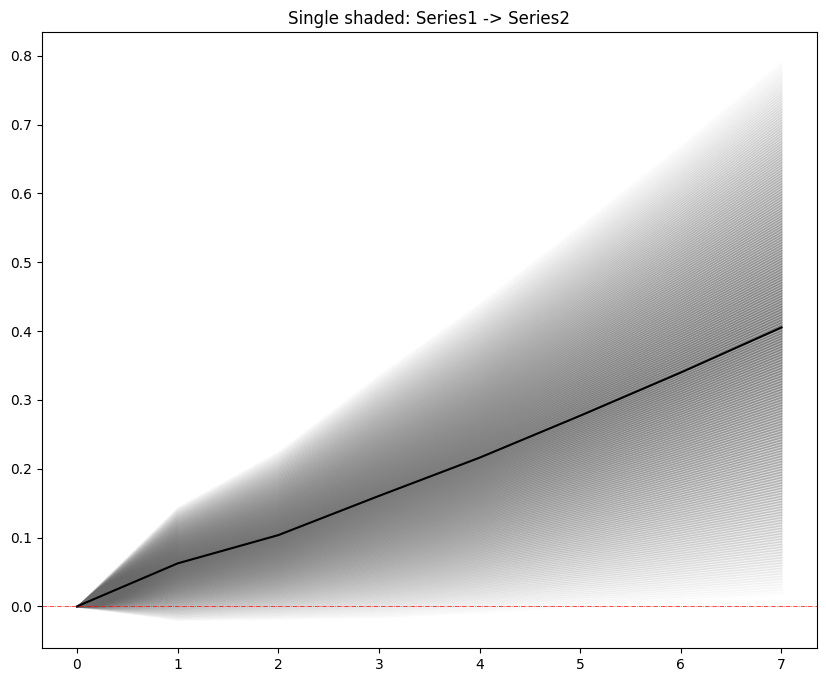

In [4]:
# 1) Single A->B shaded
fig, ax = plt.subplots(figsize=(10, 8))
plot_irf(result, "Series1", "Series2", ax=ax, direction="single", band="shaded", layout="overlay", shaded=True)
ax.axhline(0, color='r', linestyle='dashdot', linewidth=0.5)
ax.set_title("Single shaded: Series1 -> Series2")
plt.show()


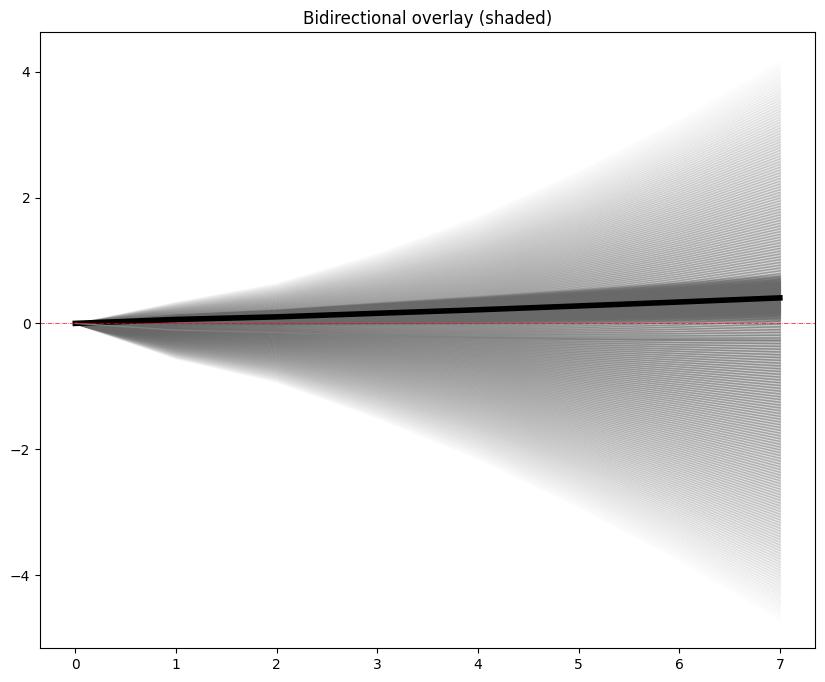

In [5]:
# 2) Bidirectional overlay shaded
fig, ax = plt.subplots(figsize=(10, 8))
plot_irf(result, "Series1", "Series2", ax=ax, direction="bi", band="shaded", layout="overlay", shaded=True)
ax.axhline(0, color='r', linestyle='dashdot', linewidth=0.5)
ax.set_title("Bidirectional overlay (shaded)")
plt.show()


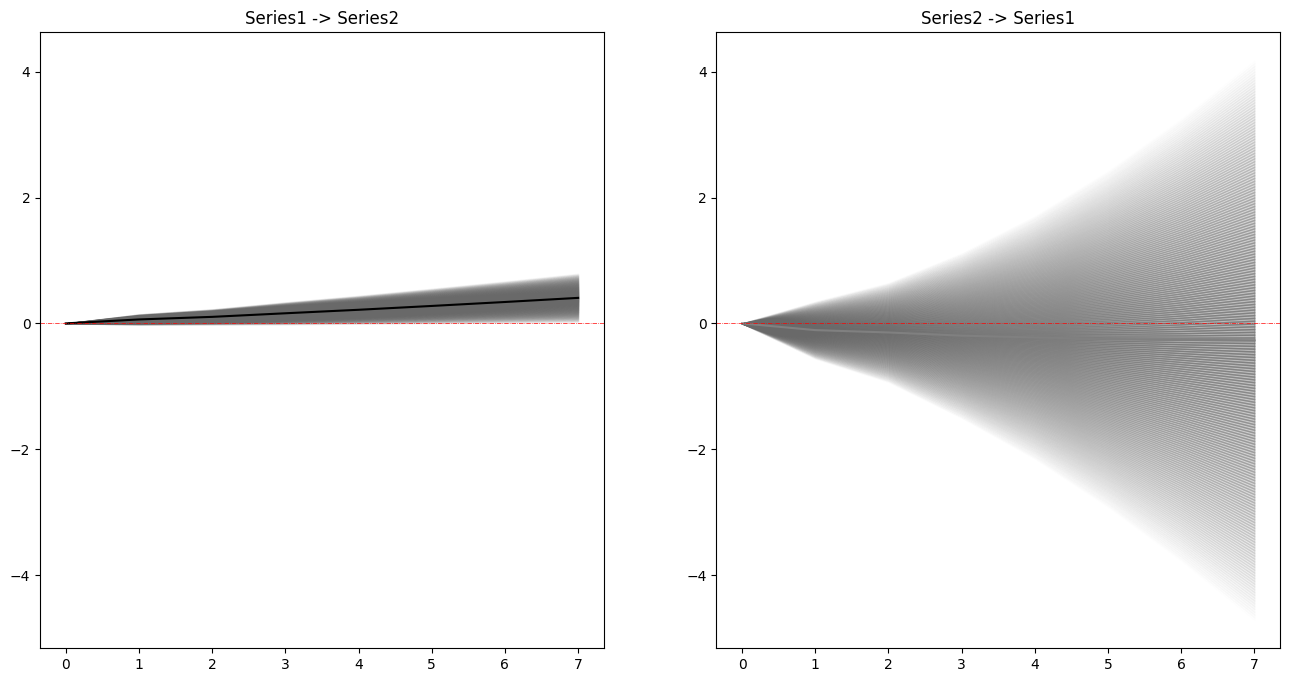

In [6]:
# 3) Bidirectional side-by-side shaded
axes = plot_irf(result, "Series1", "Series2", direction="bi", band="shaded", layout="side-by-side", shaded=True)
for a in axes:
    a.axhline(0, color='r', linestyle='dashdot', linewidth=0.5)
axes[0].set_title("Series1 -> Series2")
axes[1].set_title("Series2 -> Series1")
plt.show()


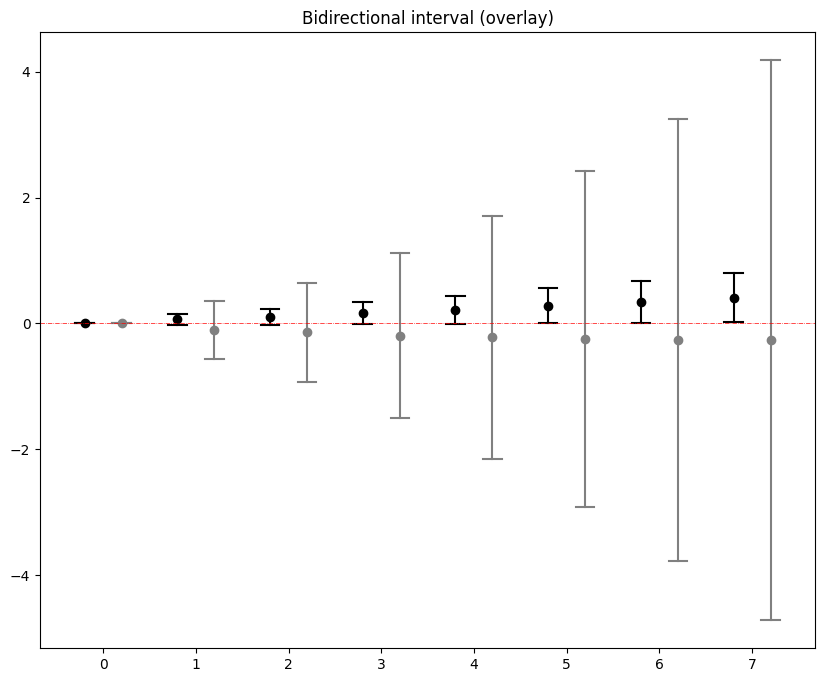

In [7]:
# 4) Bidirectional interval (errorbar-like)
fig, ax = plt.subplots(figsize=(10, 8))
plot_irf(result, "Series1", "Series2", ax=ax, direction="bi", band="interval", layout="overlay")
ax.axhline(0, color='r', linestyle='dashdot', linewidth=0.5)
ax.set_title("Bidirectional interval (overlay)")
plt.show()
